# AIVLE스쿨 2차 미니프로젝트: 신규 아파트 주차 수요 예측

<img src = "https://github.com/Jangrae/img/blob/master/parking.png?raw=true" width=800, align="left"/>

# 단계 3: 모델링

## [미션]

- 모델링을 수행합니다.
    - 전처리를 추가로 진행합니다.
    - 4개 이상의 알고리즘을 사용해 모델링을 수행합니다.
    - 각 모델에 대해 성능 튜닝을 수행합니다.
    - 성능을 비교해 최선의 모델을 선정합니다.
- 데이터 파이프라인 함수를 만듭니다.
- 새로운 데이터를 읽어와 예측을 수행합니다.

## 1. 환경설정

### (1) 로컬 수행(Anaconda)

- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [177]:
# 기본 경로
path = ''

### (4) 라이브러리 불러오기

In [387]:
# 기본 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

# 모델링용 라이브러리 불러오기
from sklearn.metrics import *
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler

# 기타 라이브러리 불러기기
import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (5) 데이터 불러오기

- joblib.dump() 함수를 사용해 base_data2.pkl 파일을 읽어옵니다.
- 읽어온 데이터를 data 데이터프레임으로 선언하고 기본 정보를 확인합니다.

In [1908]:
# 파일 읽어오기
data = joblib.load(path+'base_data4.pkl')

# 확인
data.head()

,총세대수,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,-300,10년대 이후,계단식,개별,1,109,6023.7683,0,78,0,0,5.759831e+07,400k-
1,-300,10년대 이후,복도식,개별,1,35,1569.1668,35,0,0,0,6.306200e+07,400k-
2,-300,10년대 이후,계단식,개별,1,88,7180.1396,0,88,0,0,7.219000e+07,400k-
3,300-500,10년대 이후,복도식,지역,1,943,47058.9273,0,150,216,111,9.158473e+07,400k-
4,-300,10년대 이후,복도식,개별,1,21,543.0268,15,0,0,0,5.446315e+07,200-400k


In [1910]:
dumm_cols = ['건물형태', '난방방식', '준공연도', '임대료', '총세대수']

data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)

data.head()

,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,건물형태_복도식,난방방식_중앙,난방방식_지역,준공연도_10년대 이후,준공연도_90년대,임대료_100-200k,임대료_200-400k,임대료_400k-,총세대수_300-500,총세대수_500-1000,총세대수_1000-
0,1,109,6023.7683,0,78,0,0,5.759831e+07,0,0,0,1,0,0,0,1,0,0,0
1,1,35,1569.1668,35,0,0,0,6.306200e+07,1,0,0,1,0,0,0,1,0,0,0
2,1,88,7180.1396,0,88,0,0,7.219000e+07,0,0,0,1,0,0,0,1,0,0,0
3,1,943,47058.9273,0,150,216,111,9.158473e+07,1,0,1,1,0,0,0,1,1,0,0
4,1,21,543.0268,15,0,0,0,5.446315e+07,1,0,0,1,0,0,1,0,0,0,0


<Axes: >

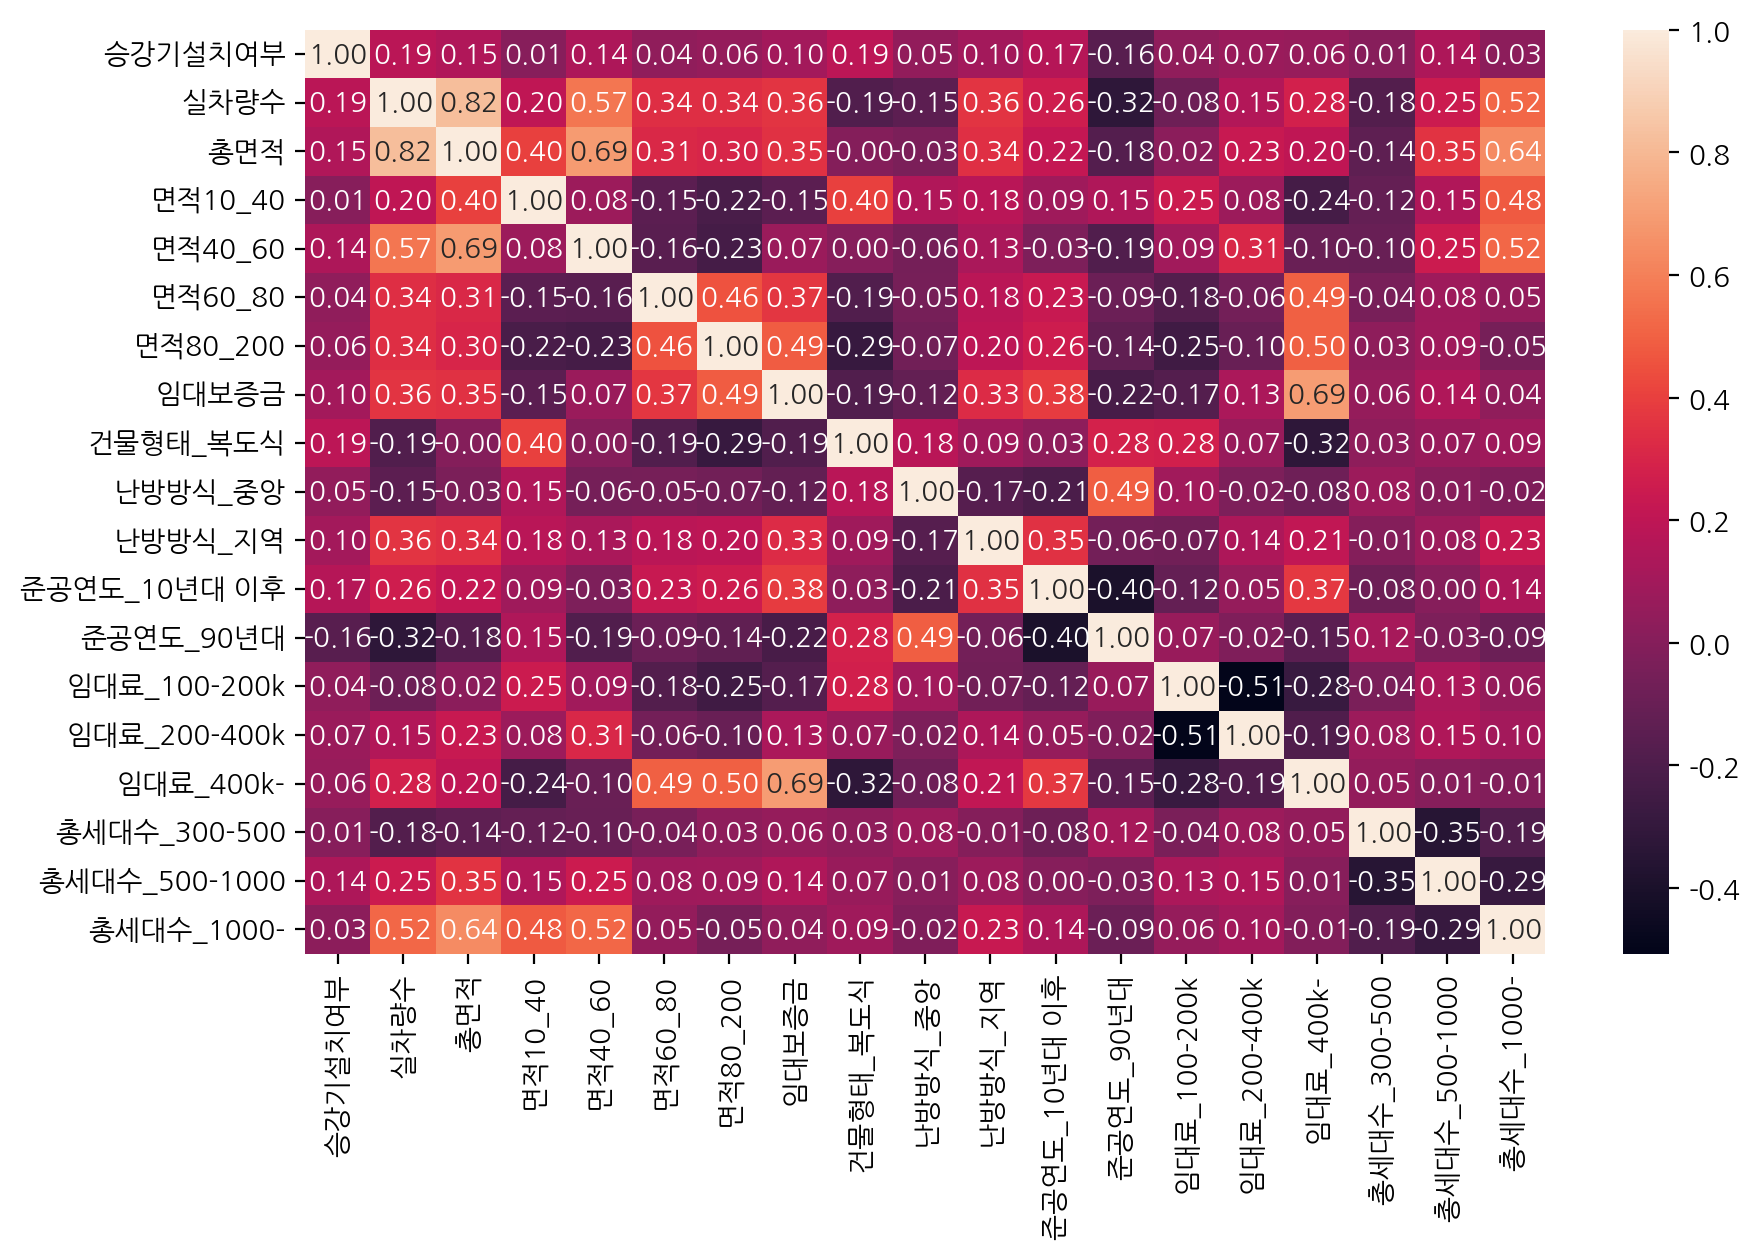

In [1912]:
plt.figure(figsize=(10,6))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    fmt='.2f')

#### 2) x, y 분리

- Target를 지정하고, x와 y로 분리합니다.

In [1914]:
target = '실차량수'

x = data.drop(columns=target)
y = data[target]

#### 3) 학습용, 평가용 분리

- 학습용, 평가용 데이터를 적절한 비율로 분리합니다.

In [1916]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=1)

#### 4) 스케일링

- 필요한 경우 스케일링을 진행합니다.
- 예를 들어 KNN 알고리즘을 사용할 경우입니다.

In [1918]:
scaler = MinMaxScaler()
x_train_s = scaler.fit_transform(x_train)
x_val_s = scaler.transform(x_val)

In [2102]:
# 실젯값, 예측값 비교 함수 만들기
def model_plot(y_test, y_pred):
    plt.figure(figsize=(10, 3))
    plt.plot(y_test.values, label='Actual', linewidth=0.7, marker='o', markersize=2)
    plt.plot(y_pred, label='Predicted', linewidth=0.7, marker='o', markersize=2)
    plt.legend()
    plt.show()

### (2) 모델 1: 알고리즘

In [1924]:
model1 = LinearRegression()

cv_score = cross_val_score(model1, x_train, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result = {}
result['LinearRegression'] = cv_score.mean()
print(result)

[0.49099217 0.77302862 0.59782628 0.6916699  0.7998865  0.61938014
 0.60111799 0.79131155 0.76209223 0.69682417]
평균: 0.6824129563181761
표준편차: 0.09741207586669626
{'LinearRegression': 0.6824129563181761}


In [1925]:
model1 = LinearRegression()

model1.fit(x_train, y_train)
y_pred = model1.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result = {}
result['LinearRegression'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 136.29864870624152
R2: 0.7115864926107345
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}}


### (3) 모델 2: 알고리즘


In [1929]:
model2 = KNeighborsRegressor(n_neighbors=5)

cv_score = cross_val_score(model2, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['KNN'] = cv_score.mean()
print(result)

[0.09853554 0.49822696 0.65667656 0.57328764 0.70961584 0.59878626
 0.66218015 0.71549146 0.55567804 0.49878526]
평균: 0.5567263708883453
표준편차: 0.16983953756225675
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': 0.5567263708883453}


In [1930]:
model2 = KNeighborsRegressor(n_neighbors=7)

model2.fit(x_train_s, y_train)
y_pred = model2.predict(x_val_s)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['KNN'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 137.46790890269153
R2: 0.7150930383502054
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}}


### (4) 모델 3: 알고리즘

In [1932]:
model3 = DecisionTreeRegressor(max_depth=7)

cv_score = cross_val_score(model3, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['DecisionTree'] = cv_score.mean()
print(result)

[0.07246386 0.21863237 0.38279534 0.49486981 0.44139014 0.79377114
 0.56320439 0.86911073 0.74760958 0.57009687]
평균: 0.5153944235425361
표준편차: 0.23865172429717535
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}, 'DecisionTree': 0.5153944235425361}


In [1933]:
model3 = DecisionTreeRegressor(max_depth=5)

model3.fit(x_train, y_train)
y_pred = model3.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['DecisionTree'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 123.15188065174716
R2: 0.7714852765335382
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}, 'DecisionTree': {'MAE': 123.15188065174716, 'R2': 0.7714852765335382}}


<BarContainer object of 18 artists>

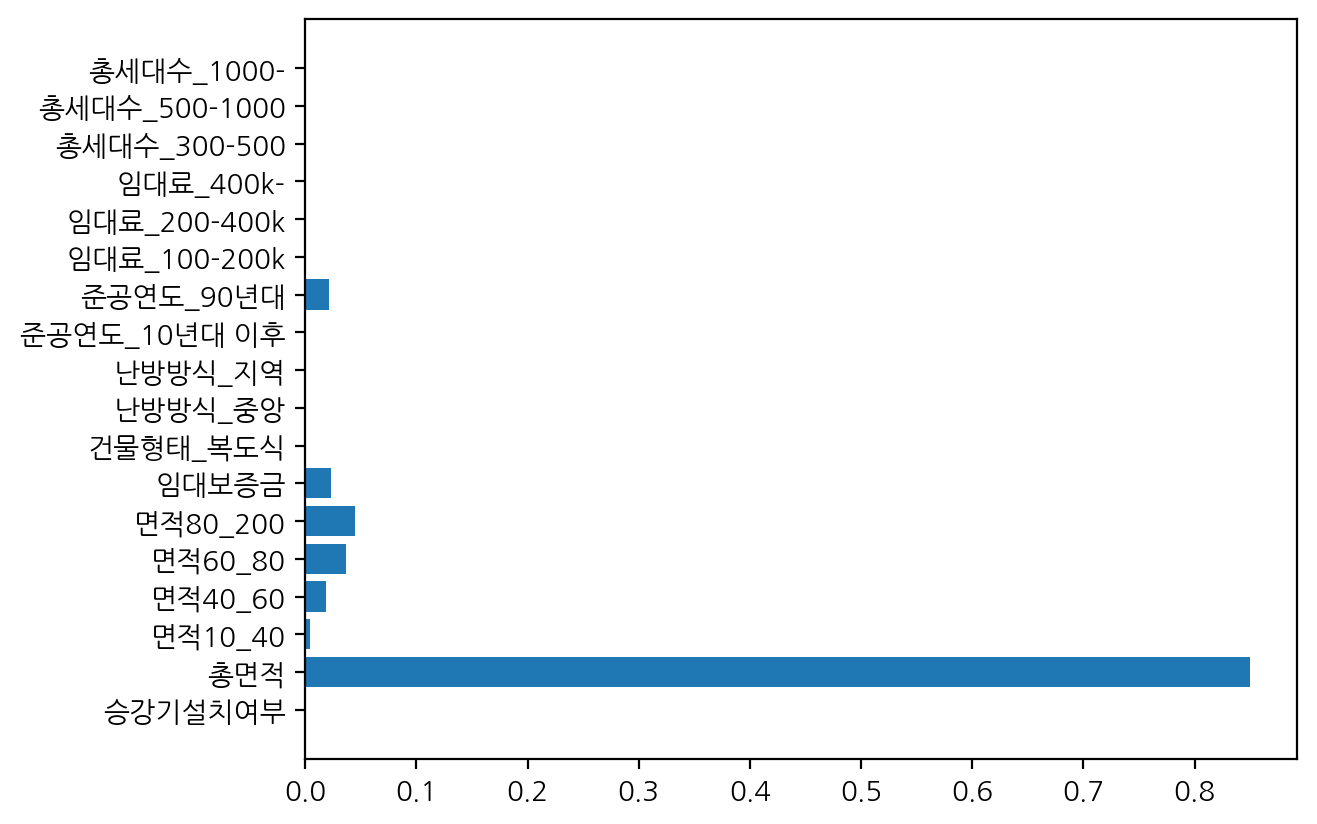

In [1934]:
plt.barh(y=list(x), width=model3.feature_importances_)

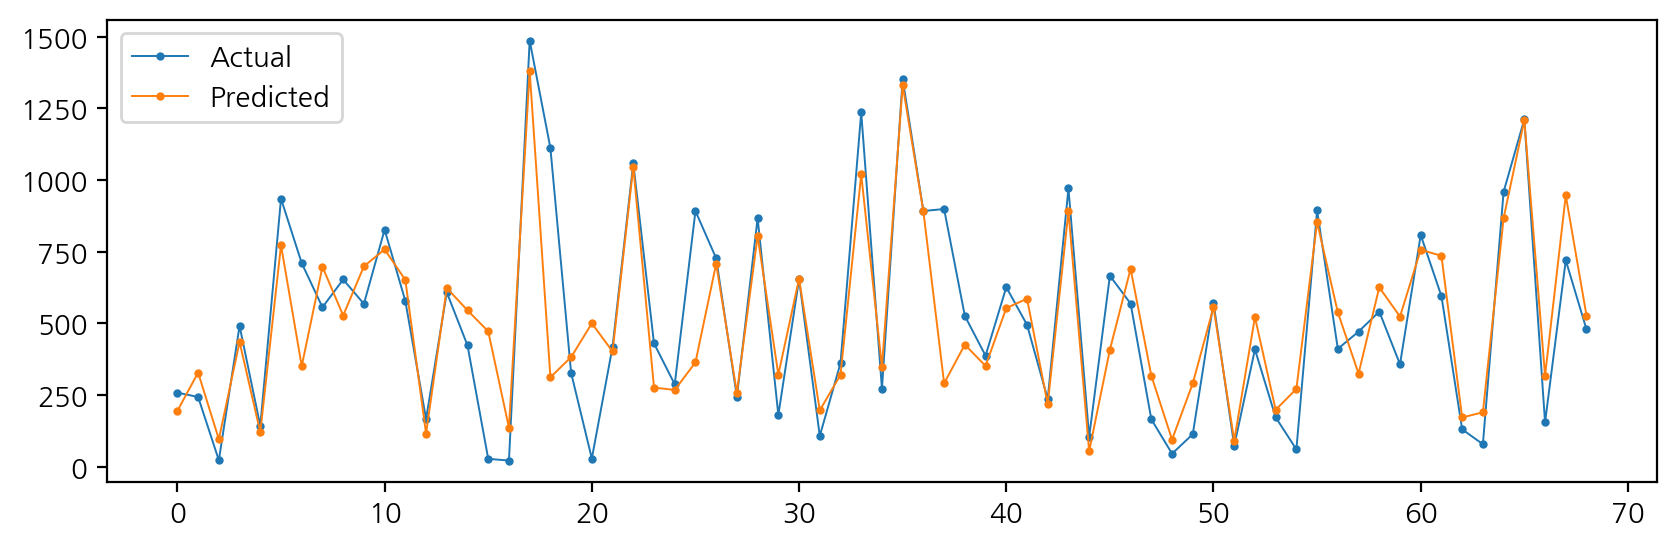

In [2104]:
model_plot(y_val, y_pred)

### (5) 모델 4: 알고리즘

In [1936]:
model4 = RandomForestRegressor(max_depth=7)

cv_score = cross_val_score(model4, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['RandomForest'] = cv_score.mean()
print(result)

[0.46862341 0.66843147 0.74715974 0.71105166 0.85443786 0.81483653
 0.61034294 0.91657329 0.84920659 0.66127059]
평균: 0.730193409249195
표준편차: 0.12786903134114463
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}, 'DecisionTree': {'MAE': 123.15188065174716, 'R2': 0.7714852765335382}, 'RandomForest': 0.730193409249195}


In [1937]:
model4 = RandomForestRegressor(max_depth=7)

model4.fit(x_train, y_train)
y_pred = model4.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['RandomForest'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 121.13605962105066
R2: 0.7464059453495463
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}, 'DecisionTree': {'MAE': 123.15188065174716, 'R2': 0.7714852765335382}, 'RandomForest': {'MAE': 121.13605962105066, 'R2': 0.7464059453495463}}


<BarContainer object of 18 artists>

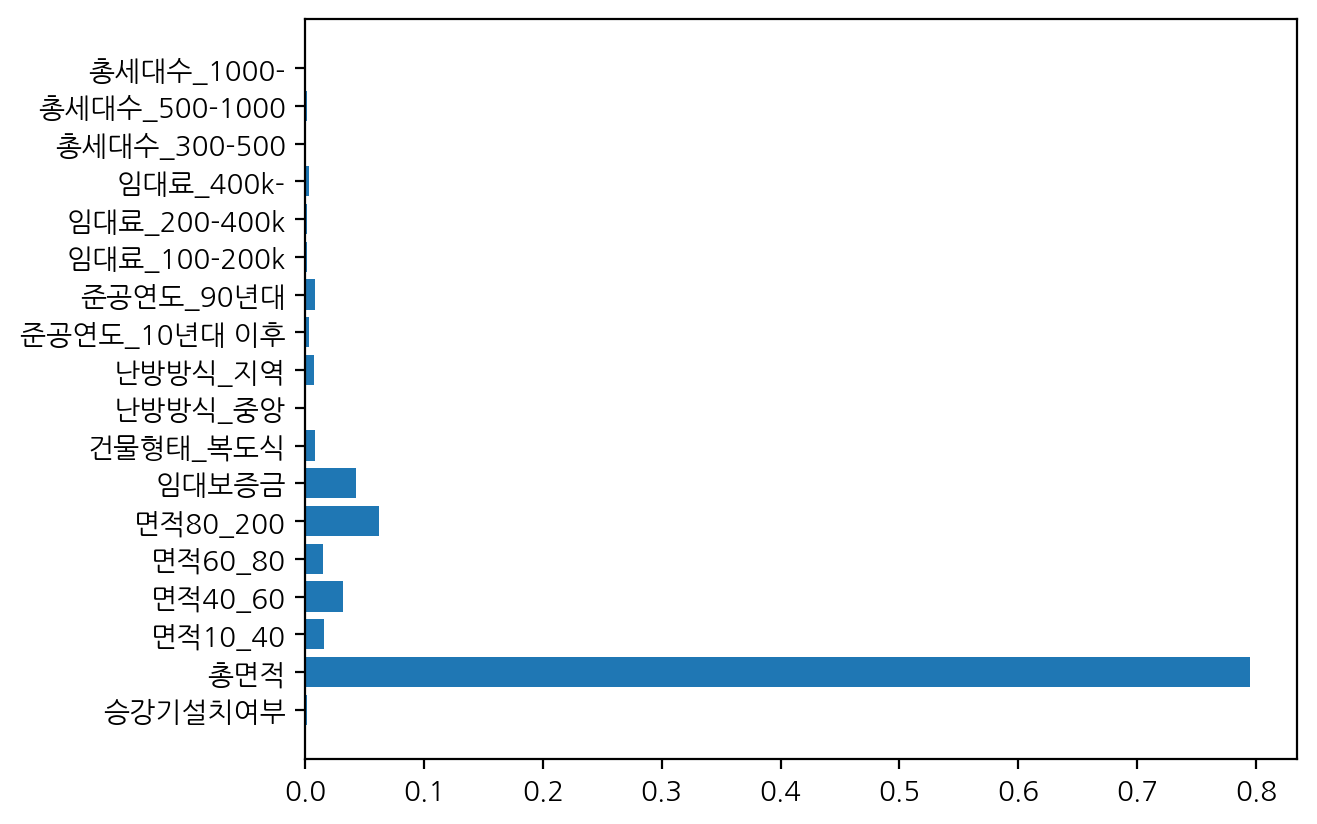

In [1938]:
# 변수 중요도
plt.barh(y=list(x), width=model4.feature_importances_)

### (6) 모델 5: 알고리즘

In [1940]:
model5 = XGBRegressor(max_depth=7)

cv_score = cross_val_score(model5, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['XGB'] = cv_score.mean()
print(result)

[0.32793603 0.55313386 0.68639967 0.72089205 0.5827571  0.80544026
 0.6074753  0.90030567 0.84446486 0.66248126]
평균: 0.6691286049922607
표준편차: 0.1571358509627723
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}, 'DecisionTree': {'MAE': 123.15188065174716, 'R2': 0.7714852765335382}, 'RandomForest': {'MAE': 121.13605962105066, 'R2': 0.7464059453495463}, 'XGB': 0.6691286049922607}


In [1941]:
model5 = XGBRegressor(max_depth=7)

model5.fit(x_train, y_train)
y_pred = model5.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['XGB'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 133.3381215247555
R2: 0.6480027922803946
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}, 'DecisionTree': {'MAE': 123.15188065174716, 'R2': 0.7714852765335382}, 'RandomForest': {'MAE': 121.13605962105066, 'R2': 0.7464059453495463}, 'XGB': {'MAE': 133.3381215247555, 'R2': 0.6480027922803946}}


### (7) 모델 6: 알고리즘

In [1944]:
model6 = LGBMRegressor(max_depth=7, verbose=-1)

cv_score = cross_val_score(model6, x_train_s, y_train, cv=10)

# 확인
print(cv_score)
print('평균:', cv_score.mean())
print('표준편차:', cv_score.std())

# 결과
result['LGBM'] = cv_score.mean()
print(result)

[0.36761259 0.71922576 0.74017467 0.74709494 0.85230023 0.78969527
 0.63216548 0.88866062 0.83619348 0.72272621]
평균: 0.729584926357926
표준편차: 0.14015362142945226
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}, 'DecisionTree': {'MAE': 123.15188065174716, 'R2': 0.7714852765335382}, 'RandomForest': {'MAE': 121.13605962105066, 'R2': 0.7464059453495463}, 'XGB': {'MAE': 133.3381215247555, 'R2': 0.6480027922803946}, 'LGBM': 0.729584926357926}


In [1946]:
model6 = LGBMRegressor(max_depth=3, verbose=-1)

model6.fit(x_train, y_train)
y_pred = model6.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('MAE:', mae)
print('R2:', r2)

result['LGBM'] = {'MAE':mae, 'R2':r2}
print(result)

MAE: 127.56550857820659
R2: 0.7186696843369285
{'LinearRegression': {'MAE': 136.29864870624152, 'R2': 0.7115864926107345}, 'KNN': {'MAE': 137.46790890269153, 'R2': 0.7150930383502054}, 'DecisionTree': {'MAE': 123.15188065174716, 'R2': 0.7714852765335382}, 'RandomForest': {'MAE': 121.13605962105066, 'R2': 0.7464059453495463}, 'XGB': {'MAE': 133.3381215247555, 'R2': 0.6480027922803946}, 'LGBM': {'MAE': 127.56550857820659, 'R2': 0.7186696843369285}}


### (8) 모델 7: 알고리즘

In [1982]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_val)
 
# 그라디언트 부스팅 회귀 모델 정의
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
 
# 모델 학습
gbr_model.fit(X_train_scaled, y_train)
 
# 예측
y_pred = gbr_model.predict(X_test_scaled)
 
# 성능 평가
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
 
print(f"R2 score: {r2 * 100:.2f}%")
print(f"MAE: {mae:.2f}")

R2 score: 70.90%
MAE: 124.66


### (7) 성능 비교

- 각 모델의 성능을 비교합니다.

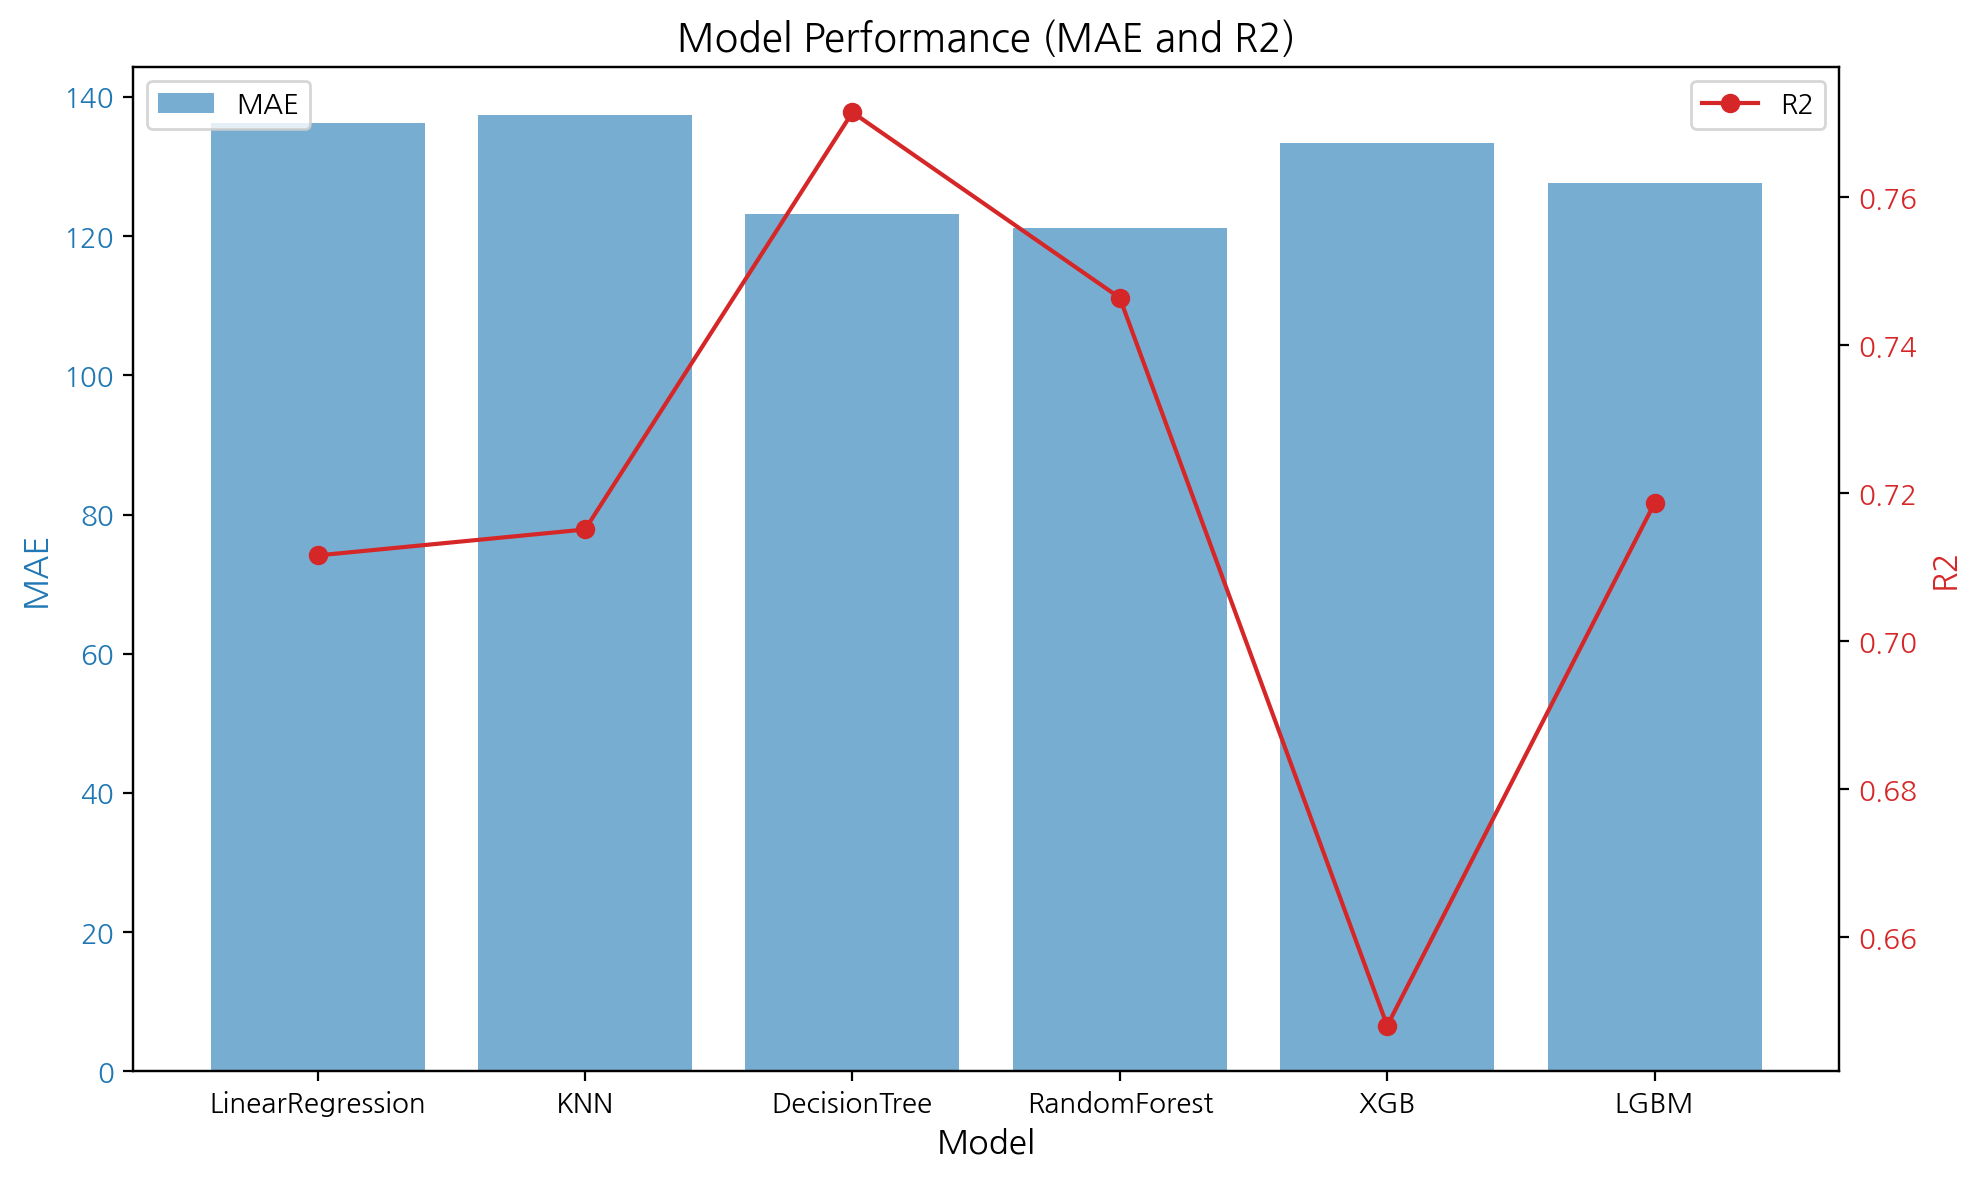

In [1948]:
# 데이터프레임으로 변환
df = pd.DataFrame(result).T

# 그래프 설정
fig, ax1 = plt.subplots(figsize=(10, 6))

# 첫 번째 y축 - MAE 막대그래프
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('MAE', fontsize=12, color='tab:blue')
ax1.bar(df.index, df['MAE'], color='tab:blue', alpha=0.6, label='MAE')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 두 번째 y축 - R2 선그래프
ax2 = ax1.twinx()
ax2.set_ylabel('R2', fontsize=12, color='tab:red')
ax2.plot(df.index, df['R2'], color='tab:red', marker='o', label='R2')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 그래프 제목
plt.title('Model Performance (MAE and R2)', fontsize=14)

# 레전드 표시
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 레이아웃 조정
fig.tight_layout()

# 그래프 출력
plt.show()

## 3. 파이프라인 구축

- 새로운 데이터를 불러오고, 이 데이터를 처리할 파이프라인 함수를 만듭니다.

### (1) New Data 불러오기

- test.xlsx 파일을 읽어와 new_data 데이터프레임으로 선언합니다.
- 해당 데이터는 '실차량수' 변수가 없는 것 외에는, 최초 데이터와 동일한 구조입니다.
- 이 데이터를 대상으로 전처리와 예측을 수행합니다.

In [2067]:
# 파일 읽어오기
new_data = pd.read_excel(path+'test.xlsx')

# 확인
new_data.head()

,단지코드,단지명,총세대수,전용면적별세대수,지역,준공일자,건물형태,난방방식,승강기설치여부,단지내주차면수,전용면적,공용면적,임대보증금,임대료
0,C0005,서울석촌 도시형주택(공임10년),20,6,서울,20121115,복도식,개별가스난방,전체동 설치,9,17.53,11.7251,50449000,263710
1,C0005,서울석촌 도시형주택(공임10년),20,10,서울,20121115,복도식,개별가스난방,전체동 설치,9,24.71,16.5275,52743000,321040
2,C0005,서울석촌 도시형주택(공임10년),20,4,서울,20121115,복도식,개별가스난방,전체동 설치,9,26.72,17.8720,53890000,332510
3,C0017,대구혁신센텀힐즈,822,228,대구경북,20180221,계단식,지역난방,NaN,824,51.87,20.9266,29298000,411200
4,C0017,대구혁신센텀힐즈,822,56,대구경북,20180221,계단식,지역난방,NaN,824,59.85,24.1461,38550000,462600


In [2068]:
new_data.isna().sum()

단지코드        0
단지명         0
총세대수        0
전용면적별세대수    0
지역          0
준공일자        0
건물형태        4
난방방식        1
승강기설치여부     9
단지내주차면수     0
전용면적        0
공용면적        0
임대보증금       0
임대료         0
dtype: int64

### (2) 데이터 파이프라인 구축

- 데이터 파이프라인 함수를 만듭니다.
- 학습 데이터에 대해 진행했던 모든 전처리 과정을 평가 데이터에도 일괄 진행해야 합니다.
    - 입력: new_data
    - 출력: 전처리가 완료된 예측 직전 데이터프레임
- 새로운 데이터에는 '실차량수' 변수가 없음을 유의합니다.
- 참고: 다음 내용들이 처리되어야 합니다.
    - 결측치 처리
    - 변수 추가
    - 불필요한 변수 제거
    - 단지 데이터, 상세 데이터 분리
    - 단지코드별 총면적 합 집계
    - 전용면적 구간별 집계 (피벗 형태)
    - 임대보증금, 임대료 평균 집계
    - 집계 결과 병합
    - 난방방식: 개별, 지역, 중앙 세 가지로 묶기
    - 승강기설치여부: 0, 1 값으로 변경
    - 단지모드, 지역 변수 제거
    - 가변수화

In [2070]:
# 파이프라인 만들기
def data_pipeline(data):
    apt01 = data.copy()

    # 결측치 처리
    apt01['건물형태'].fillna(apt01['건물형태'].mode()[0], inplace=True)
    apt01['난방방식'].fillna(apt01['난방방식'].mode()[0], inplace=True)
    apt01['승강기설치여부'].fillna(apt01['승강기설치여부'].mode()[0], inplace=True)

    # 변수 추가
    apt01['준공연도'] = apt01['준공일자']//10000
    apt01['총면적'] = (apt01['전용면적'] + apt01['공용면적']) * apt01['전용면적별세대수']

    # 불필요한 변수 제거
    drop_cols = ['단지명', '단지내주차면수', '준공일자']
    apt01.drop(columns=drop_cols, inplace=True)

    # 단지별 데이터 분리
    data01 = pd.DataFrame()
    data01 = apt01[['단지코드', '총세대수', '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부']]
    data01.drop_duplicates(inplace=True)
    data01.reset_index(drop=True, inplace=True)

    # 상세 데이터 분리
    data02 = pd.DataFrame()
    data02 = apt01[['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']]

    # 단지코드별 총 면적 합 집계
    df_area = data02.groupby('단지코드', as_index=False)[['총면적']].sum()

    # 전용면적 구간별 집계
    data02['전용면적구간'] = pd.cut(data02['전용면적'], bins=[10, 40, 60, 80, 200], labels=['면적10_40', '면적40_60', '면적60_80', '면적80_200'])

    # 단지코드, 전용면적구간 별 전용면적별세대수 합 집계
    temp = data02.groupby(['단지코드', '전용면적구간'], as_index=False)[['전용면적별세대수']].sum()

    # 전용면적구간 피벗팅
    df_pivot = temp.pivot(index='단지코드', columns='전용면적구간', values='전용면적별세대수')
    df_pivot.reset_index(drop=False, inplace=True)
    df_pivot.columns.name=None

    # 단지코드별 임대보증금, 임대료 평균 집계
    df_rent_t=data02.groupby(['단지코드','전용면적별세대수'], as_index=False)[['임대보증금','임대료']].mean()
    df_rent_t['임대보증금'] = df_rent_t['임대보증금'] * df_rent_t['전용면적별세대수']
    df_rent_t['임대료'] = df_rent_t['임대료'] * df_rent_t['전용면적별세대수']
    df_rent_t1 = df_rent_t.groupby(['단지코드'], as_index=False)[['임대보증금','임대료']].sum()
    df_rent_t2 = df_rent_t.groupby(['단지코드'], as_index=False)[['전용면적별세대수']].sum()
    
    df_rent_t = pd.merge(df_rent_t1, df_rent_t2, on='단지코드')
    df_rent_t['임대보증금'] = df_rent_t['임대보증금'] / df_rent_t['전용면적별세대수']
    df_rent_t['임대료'] = df_rent_t['임대료'] / df_rent_t['전용면적별세대수']
    df_rent_t.drop(columns='전용면적별세대수', inplace=True)

    # 집계 결과 합치기
    data01 = pd.merge(data01, df_area, how='left', on='단지코드')
    data01 = pd.merge(data01, df_pivot, how='left', on='단지코드')
    base_data = pd.merge(data01, df_rent_t, how='left', on='단지코드')

    # 난방방식 범주 수정
    base_data.loc[base_data['난방방식'].str.contains('개별'), '난방방식'] = '개별'
    base_data.loc[base_data['난방방식'].str.contains('지역'), '난방방식'] = '지역'
    base_data.loc[base_data['난방방식'].str.contains('중앙'), '난방방식'] = '중앙'

    # 범주 수정
    base_data['승강기설치여부'] = np.where(base_data['승강기설치여부'] == '전체동 설치', 1, 0)

    base_data['건물형태'] = np.where(base_data['건물형태'] == '복도식', '복도식', '계단식')

    base_data['준공연도'] = np.where(base_data['준공연도'] < 2000, '90년대', np.where(base_data['준공연도'] < 2010, '00년대', '10년대 이후'))

    # 수치형 변수 범주형 변수로 수정
    base_data['임대료'] = pd.cut(base_data['임대료'], 
                                 bins=[-np.inf, 100000, 200000, 400000, np.inf], 
                                 labels=['-100k', '100-200k', '200-400k', '400k-'])

    base_data['총세대수'] = pd.cut(base_data['총세대수'], 
                             bins=[-np.inf, 300, 500, 1000, np.inf], 
                             labels=['-300', '300-500','500-1000','1000-'])

    # 불필요한 변수 제거
    drop_cols = ['단지코드', '지역']
    base_data.drop(columns=drop_cols, inplace=True)

    # 가변수화
    dumm_cols = ['건물형태', '난방방식', '준공연도', '임대료', '총세대수']
    data = pd.get_dummies(base_data, columns=dumm_cols, drop_first=True, dtype=int)

    return data

### (3) 예측하기

- new_data를 파이프라인을 사용해 전처리한 후 가장 성능이 좋았던 모델로 예측한 결과를 확인합니다.

In [2072]:
# 데이터 전처리
data = data_pipeline(new_data)

# 확인
data.head()

,승강기설치여부,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,건물형태_복도식,난방방식_중앙,난방방식_지역,준공연도_10년대 이후,준공연도_90년대,임대료_100-200k,임대료_200-400k,임대료_400k-,총세대수_300-500,총세대수_500-1000,총세대수_1000-
0,1,766.2736,20,0,0,0,5.228420e+07,1,0,0,1,0,0,1,0,0,0,0
1,1,31396.0944,0,404,0,0,3.332857e+07,0,0,1,1,0,0,0,1,0,1,0
2,1,12450.4308,0,0,20,92,1.048609e+08,0,0,1,1,0,0,0,1,0,0,0
3,1,13081.4772,0,0,22,100,0.000000e+00,0,0,1,1,0,0,0,0,0,0,0
4,1,28141.7516,0,0,77,185,0.000000e+00,0,0,1,1,0,0,0,0,0,0,0


In [2073]:
model3.fit(x_train, y_train)

# 예측하기
predicted = model3.predict(data)

# 확인
print(predicted)

[  72.15384615  407.77272727  492.43478261  492.43478261  618.
  492.43478261  492.43478261 1107.          492.43478261  407.77272727
  269.32758621  197.90909091 1485.          672.46153846  328.8
  328.8         672.46153846  197.90909091  837.28571429  837.28571429
  269.32758621  837.28571429  837.28571429  837.28571429  837.28571429
  197.90909091  269.32758621 1292.33333333  138.5         672.46153846]


- 아파트 기본 정보에 예측한 차량수를 붙여 마무리합니다.

In [2080]:
new_data.head()

,단지코드,단지명,총세대수,전용면적별세대수,지역,준공일자,건물형태,난방방식,승강기설치여부,단지내주차면수,전용면적,공용면적,임대보증금,임대료
0,C0005,서울석촌 도시형주택(공임10년),20,6,서울,20121115,복도식,개별가스난방,전체동 설치,9,17.53,11.7251,50449000,263710
1,C0005,서울석촌 도시형주택(공임10년),20,10,서울,20121115,복도식,개별가스난방,전체동 설치,9,24.71,16.5275,52743000,321040
2,C0005,서울석촌 도시형주택(공임10년),20,4,서울,20121115,복도식,개별가스난방,전체동 설치,9,26.72,17.8720,53890000,332510
3,C0017,대구혁신센텀힐즈,822,228,대구경북,20180221,계단식,지역난방,NaN,824,51.87,20.9266,29298000,411200
4,C0017,대구혁신센텀힐즈,822,56,대구경북,20180221,계단식,지역난방,NaN,824,59.85,24.1461,38550000,462600


In [2082]:
# 결측치 처리
new_data['건물형태'].fillna(new_data['건물형태'].mode()[0], inplace=True)
new_data['난방방식'].fillna(new_data['난방방식'].mode()[0], inplace=True)
new_data['승강기설치여부'].fillna(new_data['승강기설치여부'].mode()[0], inplace=True)

# 변수 추가
new_data['준공연도'] = new_data['준공일자']//10000
new_data['총면적'] = (new_data['전용면적'] + new_data['공용면적']) * new_data['전용면적별세대수']

# 불필요한 변수 제거
drop_cols = ['단지내주차면수', '준공일자']
new_data.drop(columns=drop_cols, inplace=True)

# 단지별 데이터 분리
data01 = pd.DataFrame()
data01 = new_data[['단지코드', '총세대수', '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부']]
data01.drop_duplicates(inplace=True)
data01.reset_index(drop=True, inplace=True)

# 상세 데이터 분리
data02 = pd.DataFrame()
data02 = new_data[['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']]

# 단지코드별 총 면적 합 집계
df_area = data02.groupby('단지코드', as_index=False)[['총면적']].sum()

# 전용면적 구간별 집계
data02['전용면적구간'] = pd.cut(data02['전용면적'], bins=[10, 40, 60, 80, 200], labels=['면적10_40', '면적40_60', '면적60_80', '면적80_200'])

# 단지코드, 전용면적구간 별 전용면적별세대수 합 집계
temp = data02.groupby(['단지코드', '전용면적구간'], as_index=False)[['전용면적별세대수']].sum()

# 전용면적구간 피벗팅
df_pivot = temp.pivot(index='단지코드', columns='전용면적구간', values='전용면적별세대수')
df_pivot.reset_index(drop=False, inplace=True)
df_pivot.columns.name=None

# 단지코드별 임대보증금, 임대료 평균 집계
df_rent_t=data02.groupby(['단지코드','전용면적별세대수'], as_index=False)[['임대보증금','임대료']].mean()
df_rent_t['임대보증금'] = df_rent_t['임대보증금'] * df_rent_t['전용면적별세대수']
df_rent_t['임대료'] = df_rent_t['임대료'] * df_rent_t['전용면적별세대수']
df_rent_t1 = df_rent_t.groupby(['단지코드'], as_index=False)[['임대보증금','임대료']].sum()
df_rent_t2 = df_rent_t.groupby(['단지코드'], as_index=False)[['전용면적별세대수']].sum()

df_rent_t = pd.merge(df_rent_t1, df_rent_t2, on='단지코드')
df_rent_t['임대보증금'] = df_rent_t['임대보증금'] / df_rent_t['전용면적별세대수']
df_rent_t['임대료'] = df_rent_t['임대료'] / df_rent_t['전용면적별세대수']
df_rent_t.drop(columns='전용면적별세대수', inplace=True)

# 집계 결과 합치기
data01 = pd.merge(data01, df_area, how='left', on='단지코드')
data01 = pd.merge(data01, df_pivot, how='left', on='단지코드')
base_data = pd.merge(data01, df_rent_t, how='left', on='단지코드')

In [2086]:
# 데이터 셋 두개로 나누기
vars = ['단지코드', '총세대수', '지역', '총면적']
result = base_data[vars].copy()
result = result.drop_duplicates()
result.reset_index(drop=True, inplace=True)
new_data_unique = new_data.drop_duplicates(subset='단지코드')

# 매핑
result['단지명'] = result['단지코드'].map(new_data_unique.set_index('단지코드')['단지명'])

# 예측 결과 추가
result['예상차량수'] = predicted.round(1).astype(int)

# 확인
result

,단지코드,총세대수,지역,총면적,단지명,예상차량수
0,C0005,20,서울,766.2736,서울석촌 도시형주택(공임10년),72
1,C0017,822,대구경북,31396.0944,대구혁신센텀힐즈,407
2,C0034,112,경기,12450.4308,광교 호반마을 22단지 아파트,492
3,C0046,122,경기,13081.4772,죽미마을 휴먼시아12단지,492
4,C0055,262,경기,28141.7516,파주운정 한울마을 6단지,618
5,C0072,35,광주전남,3379.7260,벌교제석휴먼시아,492
6,C0073,47,광주전남,5154.6660,무안남악오룡마을,492
7,C0084,152,경남,17049.8200,진해 석동우림필유 아파트,1107
8,C0085,73,경남,7845.7626,김해북부 두산위브 아파트,492
9,C0112,571,경기,33959.3318,운암주공6단지아파트,407


In [2094]:
# 컬럼 순서를 새로운 순서로 지정
new_column_order = ['단지코드', '단지명', '지역', '총세대수', '총면적', '예상차량수']

# 새로운 컬럼 순서로 데이터프레임 재배열
result = result[new_column_order]

# 결과 확인
result

,단지코드,단지명,지역,총세대수,총면적,예상차량수
0,C0005,서울석촌 도시형주택(공임10년),서울,20,766.2736,72
1,C0017,대구혁신센텀힐즈,대구경북,822,31396.0944,407
2,C0034,광교 호반마을 22단지 아파트,경기,112,12450.4308,492
3,C0046,죽미마을 휴먼시아12단지,경기,122,13081.4772,492
4,C0055,파주운정 한울마을 6단지,경기,262,28141.7516,618
5,C0072,벌교제석휴먼시아,광주전남,35,3379.7260,492
6,C0073,무안남악오룡마을,광주전남,47,5154.6660,492
7,C0084,진해 석동우림필유 아파트,경남,152,17049.8200,1107
8,C0085,김해북부 두산위브 아파트,경남,73,7845.7626,492
9,C0112,운암주공6단지아파트,경기,571,33959.3318,407


In [2098]:
# 예측률 계산 (R2 score 사용)
true_values = result['총면적']  
predicted_values = result['예상차량수']
r2 = r2_score(true_values, predicted_values)
 
# 예측률 출력
print(f"모델의 예측률 (R² score): {r2}")

모델의 예측률 (R² score): -1.4473416371662515
